## Multivariate Exploratory Data Analysis - Heart Disease Dataset

### By:
Laura Granda

### Date:
2026-03-14

### Description:

Multivariate analysis of the cleaned heart disease dataset examining relationships between 3+ variables. READ-ONLY analysis: no transformations or modifications to the data.

Input: `data/03_primary/corazon_explored.parquet`

## 📚 Import libraries

In [1]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns

pd.set_option("display.float_format", "{:.2f}".format)

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
Pandas version:  2.3.3


## 💾 Load data

In [ ]:
INPUT_PATH: Path = Path("/home/lauragranda01/corazon/data/03_primary/corazon_explored.parquet")
df: pd.DataFrame = pd.read_parquet(INPUT_PATH, engine="pyarrow")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2919, 14)


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63,Male,typical,145,233,True,left ventricular hypertrophy,150,False,2.30,3,0.0,fixed,False
1,67,Male,asymptomatic,160,286,False,left ventricular hypertrophy,108,True,1.50,2,3.0,normal,True
2,67,Male,asymptomatic,120,229,False,left ventricular hypertrophy,129,True,2.60,2,2.0,reversable,True
3,37,Male,nonanginal,130,250,False,normal,187,False,3.50,3,0.0,normal,False
4,41,Female,nontypical,130,204,False,left ventricular hypertrophy,172,False,1.40,1,0.0,normal,False


In [3]:
df.dtypes

age              Int64
sex           category
chest_pain    category
rest_bp          Int64
chol             Int64
fbs            boolean
rest_ecg      category
max_hr           Int64
exang          boolean
old_peak       float64
slope         category
ca            category
thal          category
disease        boolean
dtype: object

## 📊 Target vs Numerical vs Categorical

### disease vs age vs sex

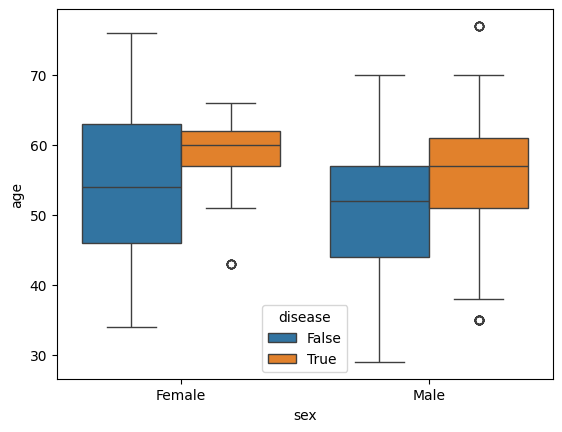

In [4]:
sns.boxplot(data=df, x="sex", y="age", hue="disease");

### disease vs age vs chest_pain

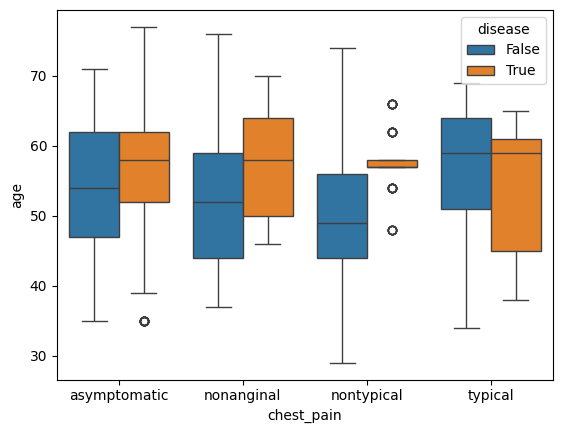

In [5]:
sns.boxplot(data=df, x="chest_pain", y="age", hue="disease");

### disease vs age vs thal

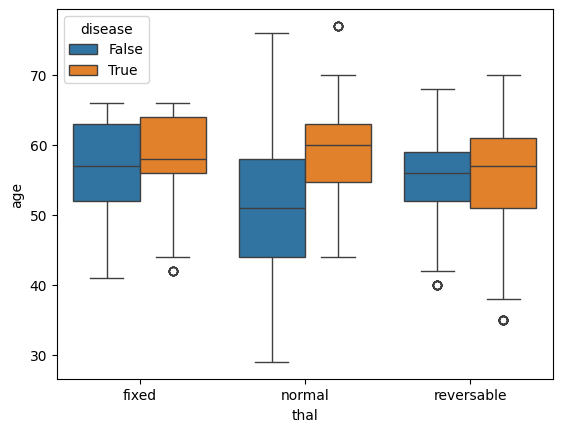

In [6]:
sns.boxplot(data=df, x="thal", y="age", hue="disease");

### disease vs max_hr vs sex

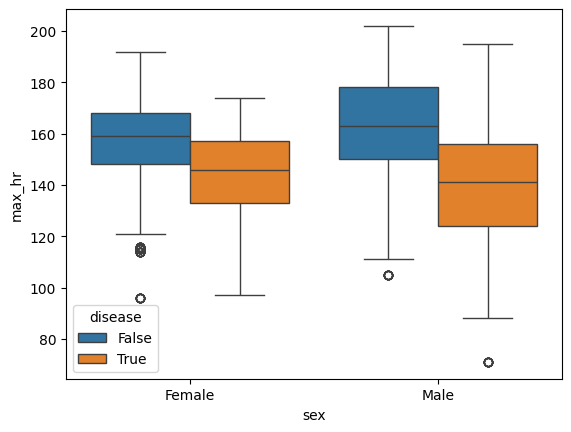

In [7]:
sns.boxplot(data=df, x="sex", y="max_hr", hue="disease");

### disease vs max_hr vs chest_pain

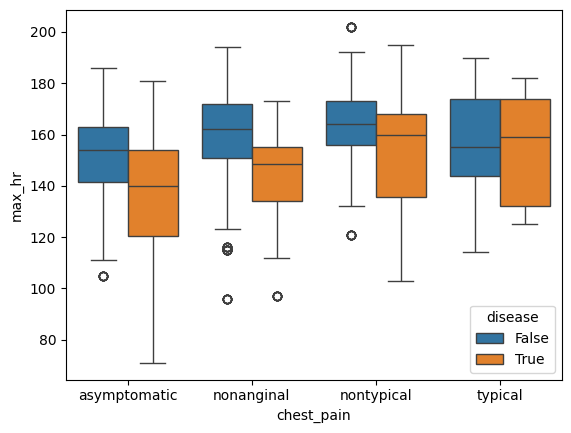

In [8]:
sns.boxplot(data=df, x="chest_pain", y="max_hr", hue="disease");

### disease vs old_peak vs chest_pain

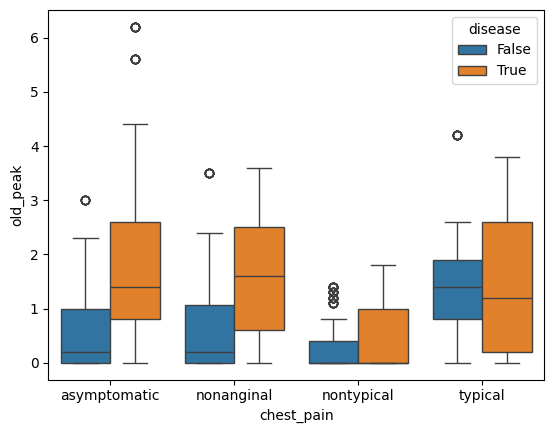

In [9]:
sns.boxplot(data=df, x="chest_pain", y="old_peak", hue="disease");

### disease vs old_peak vs thal

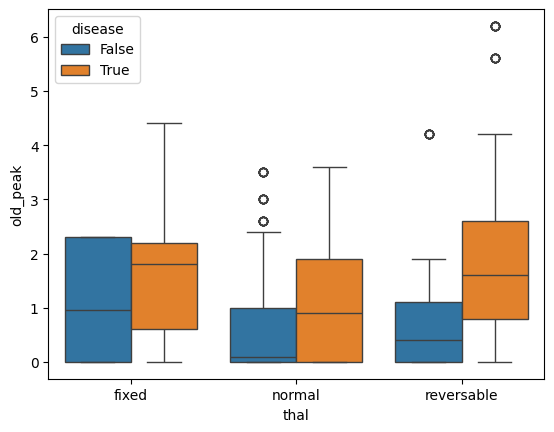

In [10]:
sns.boxplot(data=df, x="thal", y="old_peak", hue="disease");

## 📊 Target vs Categorical vs Categorical

### Groupby: disease by sex and chest_pain

In [ ]:
df[["sex", "chest_pain", "disease"]].groupby(["chest_pain", "sex"], observed=True).mean() * 100

disease
chest_pain   sex            
asymptomatic Female    55.67
             Male      79.73
nonanginal   Female     2.43
             Male      33.33
nontypical   Female    10.40
             Male      21.38
typical      Female     0.00
             Male      36.36

### Catplot: disease by sex faceted by chest_pain (count)

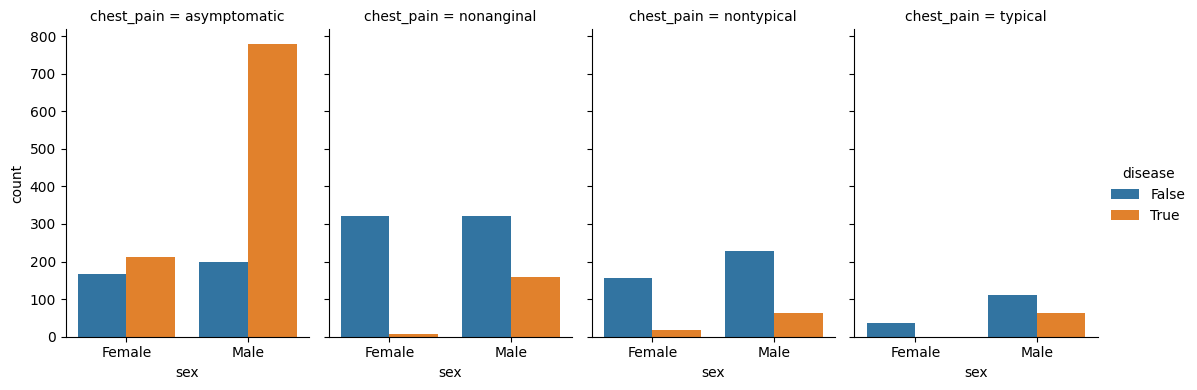

In [12]:
sns.catplot(
    data=df,
    x="sex",
    hue="disease",
    col="chest_pain",
    kind="count",
    height=4,
    aspect=0.7,
);

### Catplot: disease by sex and chest_pain (point)

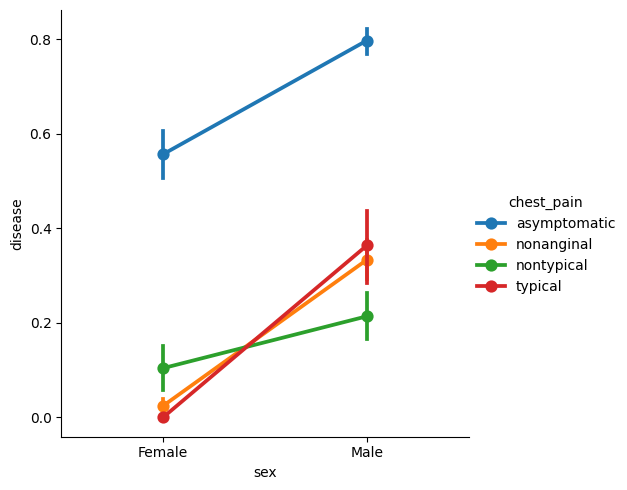

In [13]:
sns.catplot(data=df, x="sex", y="disease", hue="chest_pain", kind="point");

### Catplot: disease by chest_pain and sex (point)

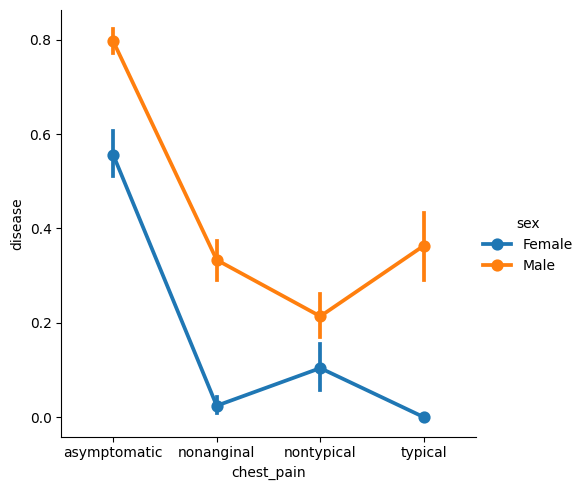

In [14]:
sns.catplot(data=df, x="chest_pain", y="disease", hue="sex", kind="point");

### Catplot: disease by sex and chest_pain (bar)

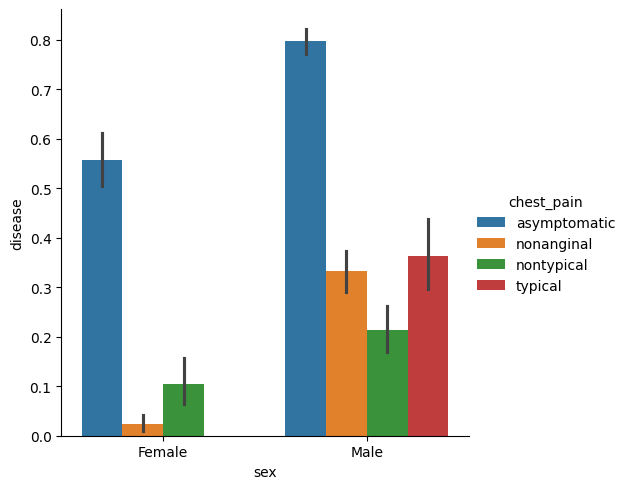

In [15]:
sns.catplot(data=df, x="sex", y="disease", hue="chest_pain", kind="bar");

### Groupby: disease by sex and thal

In [16]:
df[["sex", "thal", "disease"]].groupby(["thal", "sex"], observed=True).mean() * 100

disease
thal       sex            
fixed      Female   100.00
           Male      65.82
normal     Female    14.27
           Male      29.77
reversable Female    87.32
           Male      74.51

### Catplot: disease by sex faceted by thal (count)

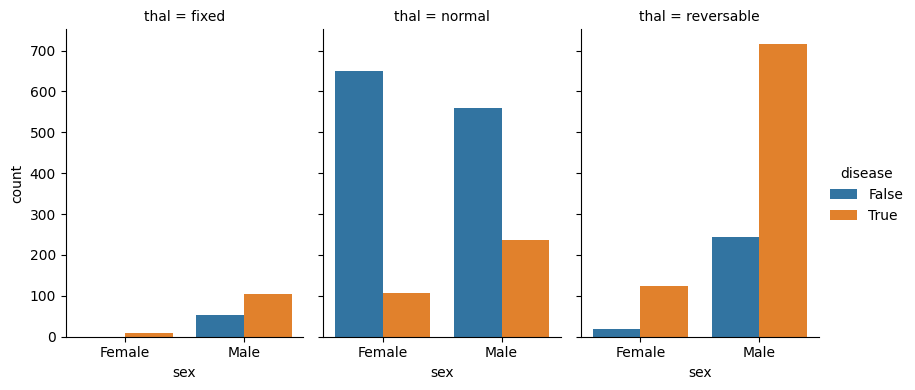

In [17]:
sns.catplot(
    data=df,
    x="sex",
    hue="disease",
    col="thal",
    kind="count",
    height=4,
    aspect=0.7,
);

### Catplot: disease by thal and sex (bar)

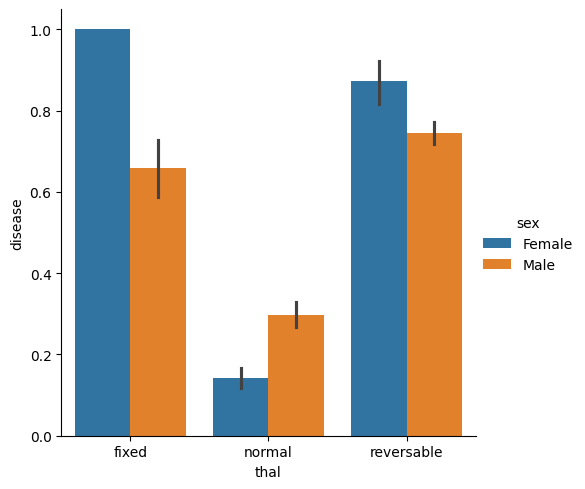

In [18]:
sns.catplot(data=df, x="thal", y="disease", hue="sex", kind="bar");

### Multi-level groupby: disease by sex, chest_pain, and thal

In [19]:
df[["sex", "chest_pain", "thal", "disease"]].groupby(
    ["thal", "chest_pain", "sex"], observed=True
).agg(["count", "mean"])

disease     
                                 count mean
thal       chest_pain   sex                
fixed      asymptomatic Female       9 1.00
                        Male       100 0.74
           nonanginal   Male        17 1.00
           nontypical   Male        19 0.53
           typical      Male        18 0.00
normal     asymptomatic Female     253 0.35
                        Male       239 0.57
           nonanginal   Female     291 0.00
                        Male       279 0.17
           nontypical   Female     172 0.10
                        Male       189 0.08
           typical      Female      37 0.00
                        Male        83 0.43
reversable asymptomatic Female     113 1.00
                        Male       618 0.89
           nonanginal   Female      26 0.31
                        Male       180 0.53
           nontypical   Male        79 0.44
           typical      Male        73 0.37

## 📊 Numerical vs All Numerical Variables

### Pairplot of numerical variables

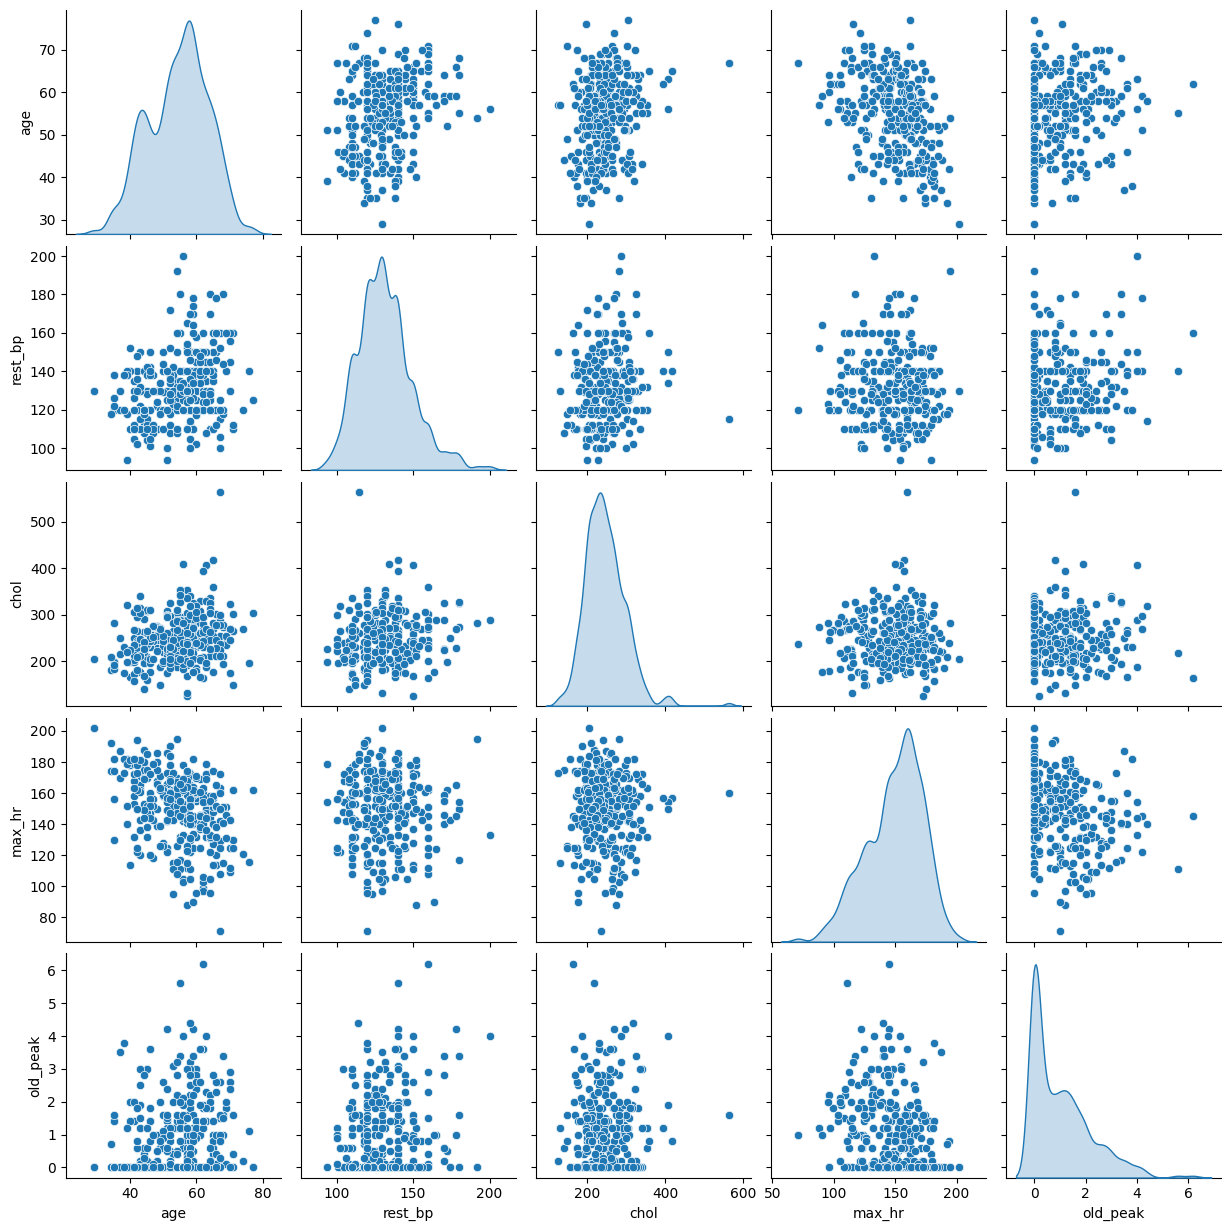

In [20]:
numerical_columns = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
sns.pairplot(df[numerical_columns].dropna().astype("float64"), diag_kind="kde");

### Pairplot of numerical variables colored by disease

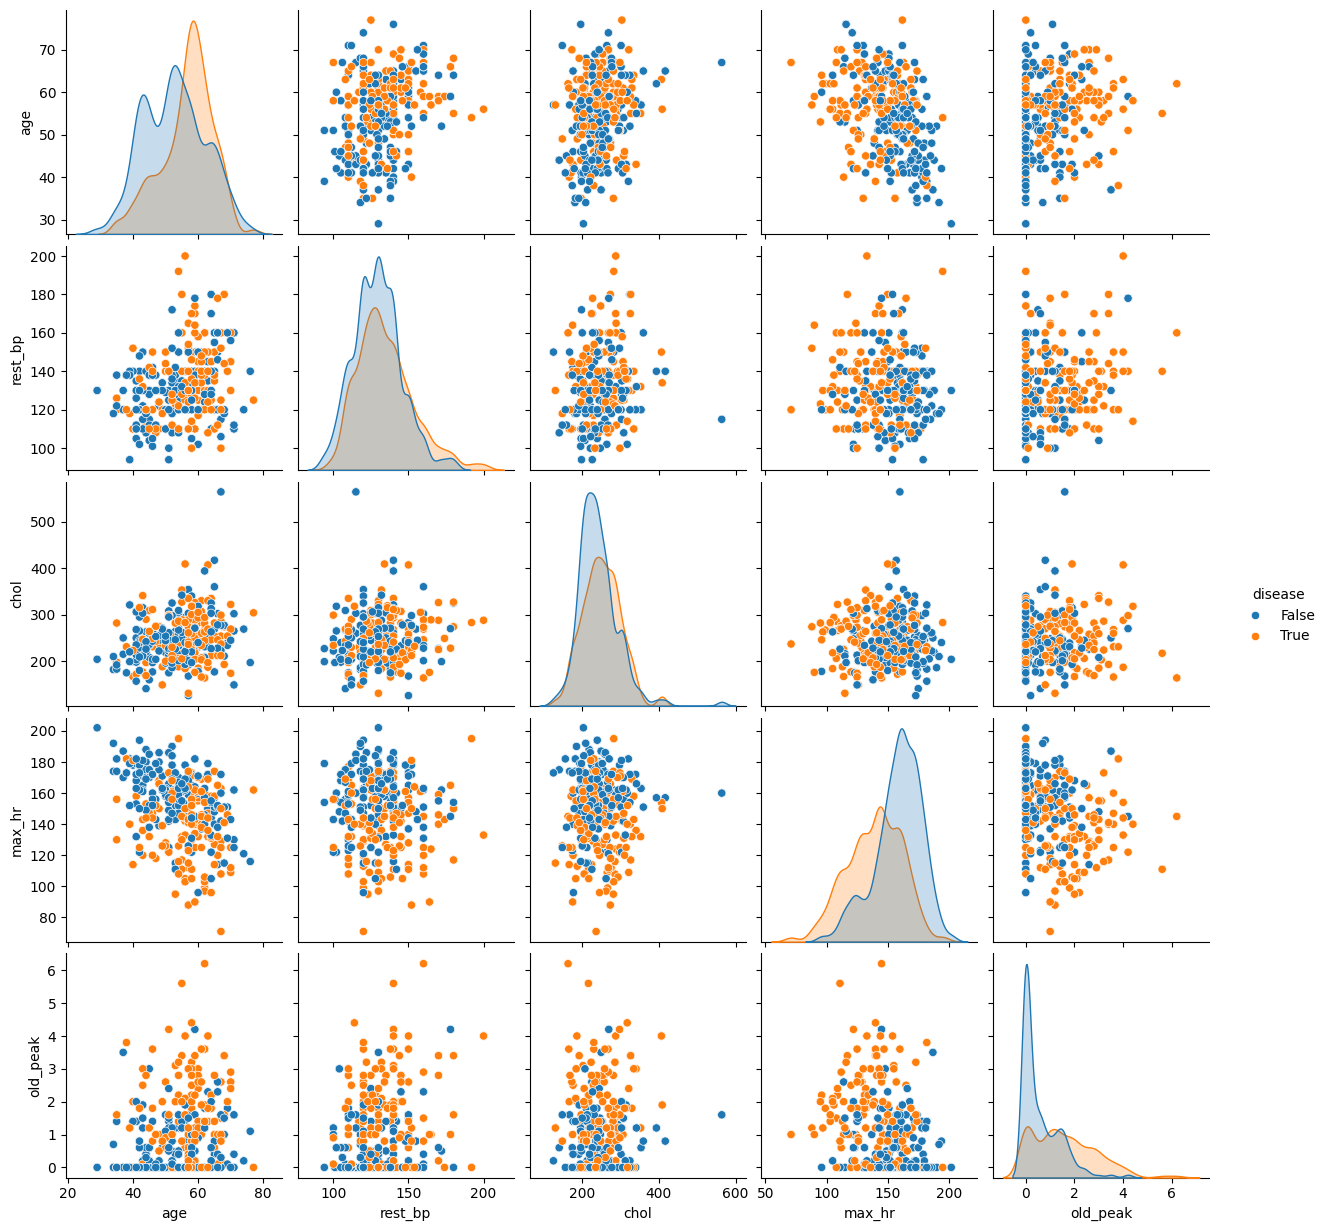

In [21]:
plot_df = df[[*numerical_columns, "disease"]].dropna()
plot_df[numerical_columns] = plot_df[numerical_columns].astype("float64")
plot_df["disease"] = plot_df["disease"].astype(str)
sns.pairplot(plot_df, hue="disease", diag_kind="kde");

## 📊 Analysis of Results and Conclusions

### Key Multivariate Findings

**Target vs Numerical vs Categorical:**
- Disease patients show lower max_hr across all categorical groups (sex, chest_pain, thal)
- Disease patients show higher old_peak across all categorical groups
- Age differences are modest across disease groups when stratified by categorical features
- Chest pain type and thal defect type act as important modifiers of the numerical relationships

**Target vs Categorical vs Categorical:**
- Sex × Chest pain interactions: asymptomatic males have >79% disease rate
- Sex × Thal interactions: reversable thal defect in males strongly associated with disease
- Three-way interactions (sex, chest_pain, thal) show disease rates varying from near 0% to >85%
- Males with asymptomatic chest pain and reversable thal defect have very high disease risk

**Numerical Variables:**
- Pairplot reveals disease patients cluster in lower max_hr and higher old_peak regions
- Age-max_hr relationship differs by disease status (disease shows steeper decline with age)
- Cholesterol shows weak numerical discrimination but may be important in categorical interactions
- Rest BP shows moderate separation between disease groups